In [43]:
import torch
import torch.nn as nn
import torch.optim as optimizer
from torch.utils.data import Dataset , DataLoader , random_split
import torchvision
from torchvision import datasets , transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report

# Loading the Fashion MNINST

In [16]:
data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform = transforms.ToTensor()
)
test_data = datasets.FashionMNIST(
    root = 'data',
    train = False,
    download = True,
    transform = transforms.ToTensor()
)
# Split based on the indices
val_size = int(len(data) * 0.2)
train_size = len(data) - val_size
train_data , val_data = random_split(data , [train_size , val_size])

100.0%
100.0%
100.0%
100.0%


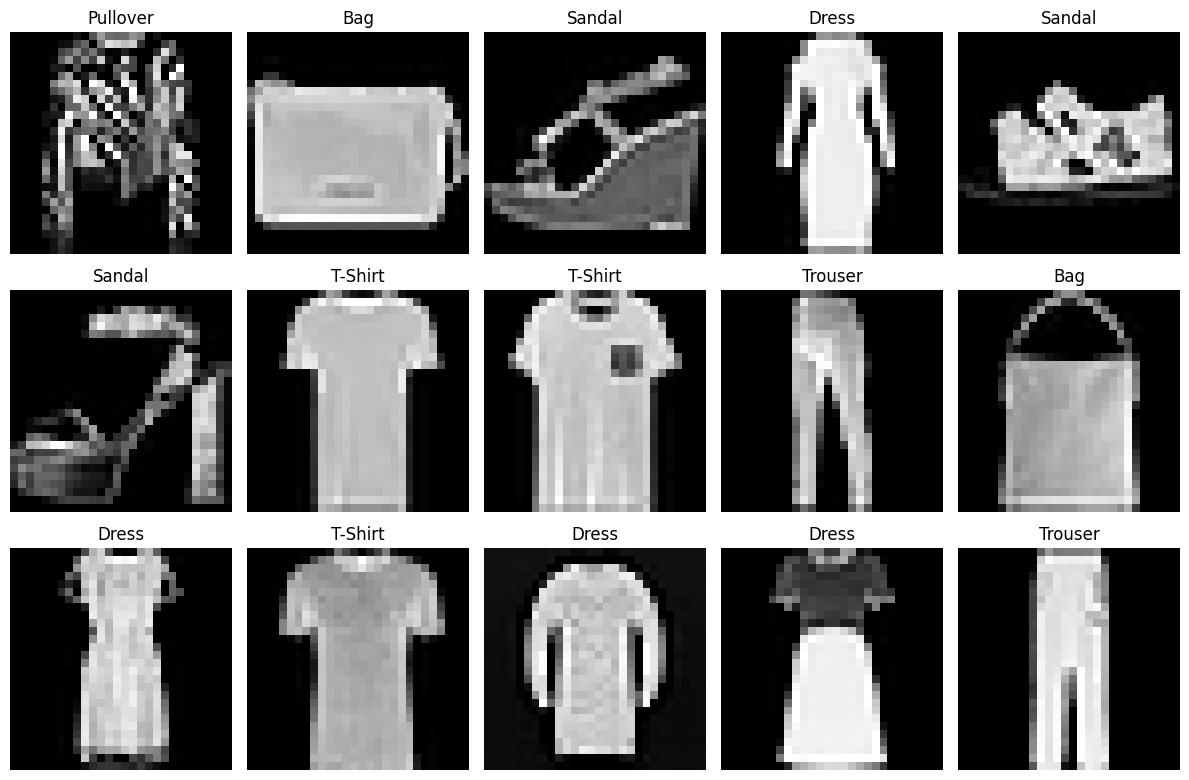

In [17]:

labels_map = {
    0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"
}

def visualize_samples(dataset, num_samples=15):
    plt.figure(figsize=(12, 8))

    for i in range(num_samples):
        idx = torch.randint(len(dataset), size=(1,)).item()
        image, label = dataset[idx]

        plt.subplot(3, 5, i + 1)
        plt.title(labels_map[label])
        plt.axis("off")

        plt.imshow(image.squeeze(), cmap="gray")

    plt.tight_layout()
    plt.show()

visualize_samples(train_data)

In [18]:
train_data.indices[:10]

[58631, 44059, 42235, 10487, 19081, 49879, 40874, 33918, 7306, 52136]

In [19]:
# Select only those rows that are selected for train
train_images = data.data[train_data.indices].reshape((train_size,784))
train_labels = nn.functional.one_hot(data.targets[train_data.indices] , num_classes=10).float()
val_images = data.data[val_data.indices].reshape((val_size,784))
val_labels = nn.functional.one_hot(data.targets[val_data.indices] , num_classes=10).float()
test_images = test_data.data.reshape((10000,784))
test_labels = nn.functional.one_hot(test_data.targets , num_classes=10).float()

In [20]:
print("Train Data")
print(train_images.shape)
print(train_labels.shape)
print("Train Data")
print(val_images.shape)
print(val_labels.shape)
print("Test Data")
print(test_images.shape)
print(test_labels.shape)

Train Data
torch.Size([48000, 784])
torch.Size([48000, 10])
Train Data
torch.Size([12000, 784])
torch.Size([12000, 10])
Test Data
torch.Size([10000, 784])
torch.Size([10000, 10])


# Creating the Custom Dataset class

In [21]:
class FashionMNISTDataset(Dataset):
    def __init__(self, images , labels):
        self.images = images
        self.labels = labels
    def __len__(self):
        return self.images.shape[0]
    def  __getitem__(self,index):
        return self.images[index] / 255 , self.labels[index]


In [22]:
train_dataset = FashionMNISTDataset(train_images , train_labels)
val_dataset = FashionMNISTDataset(val_images , val_labels)
test_dataset = FashionMNISTDataset(test_images , test_labels)

# Main Section

In [23]:
batch_size = 2048
train_batches = DataLoader(train_dataset , batch_size=batch_size,shuffle=True)
val_batches = DataLoader(val_dataset , batch_size=batch_size,shuffle=False)
test_batches = DataLoader(test_dataset , batch_size=batch_size , shuffle=False)

# ANN

In [33]:
class ANN_NN(nn.Module):
    def __init__(self,input_size):
        super().__init__()
        self.out = nn.Sequential(
            nn.Linear(input_size , 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.6),

            nn.Linear(512 , 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256 , 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128 , 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32,10)
        )
    def forward(self,x):
        out = self.out(x)
        return out

In [ ]:
device = torch.device('cpu')
model = ANN_NN(train_images.shape[1]).to(device)
lr = 0.001
optim = optimizer.Adam(model.parameters() , lr=lr , weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=3)

loss_fn = nn.CrossEntropyLoss()
epoch = 100
val_losses = []
train_losses = []
for i in range(epoch):
    model.train()
    train_loss_epoch = 0
    train_acc_epoch = 0
    for images , labels in train_batches:
        images = images.to(device)
        labels = labels.to(device)

        out = model(images)
        loss = loss_fn(out , labels)

        acc = (out.argmax(dim=1) == labels.argmax(dim=1)).float().mean()
        train_acc_epoch += acc.item()

        train_loss_epoch += loss.item()
        optim.zero_grad()
        loss.backward()
        optim.step()
        
    model.eval()
    val_loss_epoch = 0
    val_acc_epoch = 0
    with torch.no_grad():
        for val_images , val_labels in val_batches:
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)
            val_out = model(val_images)
            val_loss = loss_fn(val_out , val_labels)
            val_loss_epoch += val_loss.item()

            val_acc = (val_out.argmax(dim=1) == val_labels.argmax(dim=1)).float().mean()
            val_acc_epoch += val_acc.item()
            
    avg = train_loss_epoch / len(train_batches)
    val_avg = val_loss_epoch / len(val_batches)
    train_acc_avg = train_acc_epoch / len(train_batches)
    val_acc_avg = val_acc_epoch / len(val_batches)
    train_losses.append(avg)
    val_losses.append(val_avg)
    scheduler.step(val_avg)
    print(f"epoch {i+1} : Train loss {avg} , Val loss {val_avg} , Train Accuracy {train_acc_avg*100:.4f} , Val Accuracy {val_acc_avg*100:.4f}")


epoch 1 : Train loss 1.9999658465385437 , Val loss 1.6768776377042134 , Train Accuracy 32.5062 , Val Accuracy 56.8493
epoch 2 : Train loss 1.5597192893425624 , Val loss 1.1882608532905579 , Train Accuracy 57.0589 , Val Accuracy 72.6781
epoch 3 : Train loss 1.2521855930487316 , Val loss 0.9656114478905996 , Train Accuracy 67.2817 , Val Accuracy 74.2797
epoch 4 : Train loss 1.0373211279511452 , Val loss 0.7725708186626434 , Train Accuracy 71.4693 , Val Accuracy 75.6488
epoch 5 : Train loss 0.8909808918833733 , Val loss 0.6669663886229197 , Train Accuracy 73.7066 , Val Accuracy 78.8349
epoch 6 : Train loss 0.7930513545870781 , Val loss 0.6007469693819681 , Train Accuracy 75.9577 , Val Accuracy 81.7485
epoch 7 : Train loss 0.7256485472122828 , Val loss 0.5472456216812134 , Train Accuracy 77.9669 , Val Accuracy 82.5431
epoch 8 : Train loss 0.6731963381171227 , Val loss 0.511095349987348 , Train Accuracy 79.5134 , Val Accuracy 82.7518
epoch 9 : Train loss 0.628782885770003 , Val loss 0.46735

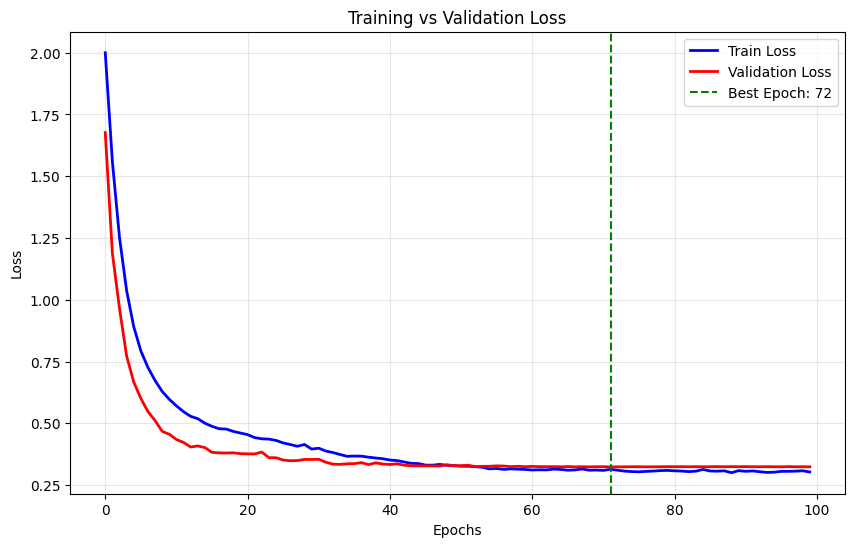

In [39]:

def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', color='red', linewidth=2)

    min_val_loss = min(val_losses)
    min_idx = val_losses.index(min_val_loss)
    plt.axvline(x=min_idx, color='green', linestyle='--', label=f'Best Epoch: {min_idx+1}')

    plt.title('Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_loss(train_losses, val_losses)

# Evaluation

In [42]:
with torch.no_grad():
    acc = 0
    for images , labels in test_batches:
        images = images.to(device)
        labels = labels.to(device)
        out = model(images)
        acc += (out.argmax(dim=1) == labels.argmax(dim=1)).float().mean()
    acc_avg = acc / len(test_batches)
    print(f"Test Accuracy {acc_avg*100:.4f}")

Test Accuracy 89.2491


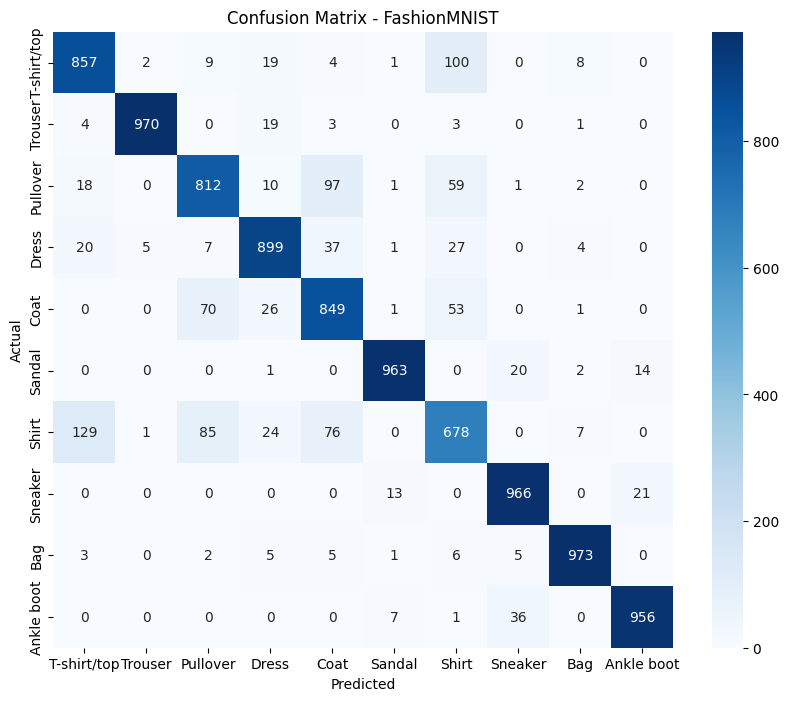

--------------------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.86      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.81      0.82      1000
       Dress       0.90      0.90      0.90      1000
        Coat       0.79      0.85      0.82      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.73      0.68      0.70      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Per-Class Accuracy:
T-shirt/top: 85.70%
Trouser: 97.00%
Pullover: 81.20%
Dress: 89.90%
Coat: 84.90%
Sandal: 96.30%
Shirt: 67.80%
Sneaker:

In [41]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            labels = torch.argmax(labels, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - FashionMNIST")
    plt.show()

    print("--"*40)
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))
    class_accuracy = cm.diagonal() / cm.sum(axis=1)

    print("Per-Class Accuracy:")
    for idx, acc in enumerate(class_accuracy):
        print(f"{classes[idx]}: {acc*100:.2f}%")
    overall_acc = np.sum(cm.diagonal()) / np.sum(cm)
    print(f"Overall Accuracy: {overall_acc*100:.2f}%")

evaluate_model(model, test_batches, device)